# Surface-deformation companion (executable) — bilevel optimisation

**Runnable companion to [`deformation.md`](deformation.md).** The framing (inner linear
SF solve, outer non-linear CMA-ES / NSGA-II, when to use deformation) stays in
`deformation.md`; here the **outer loop is run** with Optuna and the trade-off /
Pareto-front numbers are produced live. All compute drives the shipped demo
`demo_planar_uniform_fem_psi_advanced.run_deformation_search` (the exact `--deform`
optimiser used by the CLI), so this notebook *is* the demo's `--minimize-reg` and
`--pareto` paths.

- **Inner loop** (linear, ~1 s): given a surface, find `psi` via the H1 min-seminorm /
  `RegularizedTSVD`.
- **Outer loop** (non-linear): vary a Gaussian-bump surface deformation; CMA-ES for the
  penalty form, NSGA-II for the Pareto front.

Two studies on the planar uniform-`Bz` benchmark:

- **(A)** penalty form `min ψᵀSψ s.t. RMS ≤ ε` (`--minimize-reg --eps-rms 0.025`);
- **(B)** the `(RMS, ψᵀSψ)` Pareto front (`--pareto`, NSGA-II).


In [1]:
import sys, time
from types import SimpleNamespace
from pathlib import Path
import numpy as np
import radia
EX = Path(radia.__file__).resolve().parents[2] / "examples" / "stream_function"
assert (EX / "demo_planar_uniform_fem_psi_advanced.py").exists(), f"shipped demos not found: {EX}"
sys.path.insert(0, str(EX))

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

import optuna
import demo_planar_uniform_fem_psi_advanced as ADV
print("radia :", radia.__file__)
print("optuna:", optuna.__version__)

# Shared planar uniform-Bz benchmark + bump deformation (deformation.md defaults).
def make_args(**over):
    base = dict(plane_half=0.25, maxh=0.025, order=2,
                target_half=0.05, target_z=0.10, n_target=5, B0=1.0e-3,
                n_sample=81, nlevels=12, regularize="h1", sigma_cf=None, jmax=50.0,
                deform=True, deform_params="bump",
                minimize_reg=False, pareto=False, eps_rms=0.02, reg_penalty=100.0)
    base.update(over)
    return SimpleNamespace(**base)

TARGET_ARGS = {"half": 0.05, "z": 0.10, "n": 5}


radia : \\192.168.11.100\work\00_CAE\Radia\01_GitHub\src\radia\__init__.py
optuna: 4.9.0


## Flat baseline (no deformation)

The reference point: solve the inner SF problem on the **flat** plane (`surface_z_fn=None`)
and record both the single-stroke RMS and the regularisation norm `ψᵀSψ` (here `S = H1`
seminorm = surface-current L²).

In [2]:
from ngsolve import TaskManager
t0 = time.time()
flat = ADV.solve_and_evaluate(0.25, 0.025, 2, TARGET_ARGS, 1.0e-3,
                              regularize="h1", surface_z_fn=None,
                              n_sample=81, nlevels=12, compute_reg_norm=True)
print(f"flat baseline ({time.time()-t0:.1f} s): RMS = {flat['rms']*100:.2f} %,"
      f"  reg_norm psi^T S psi = {flat['reg_norm']:.3e}")


flat baseline (0.7 s): RMS = 2.09 %,  reg_norm psi^T S psi = 2.590e+06


## (A) Penalty form — `min ψᵀSψ s.t. RMS ≤ ε`

The standard MRI-shim / gradient-coil formulation: *the lowest-energy coil that meets the
field-uniformity spec*. The constraint enters as a quadratic penalty scaled by the first
trial's `reg_norm`; CMA-ES minimises `reg_norm + reg_scale·penalty_weight·max(0, RMS/ε−1)²`.
The study tracks `best_feasible` (lowest `reg_norm` among trials with `RMS ≤ ε`)
separately — that is the engineering answer.

In [3]:
ARGS_PEN = make_args(minimize_reg=True, eps_rms=0.025, deform_trials=10)
t0 = time.time()
study_pen = ADV.run_deformation_search(ARGS_PEN, trials=ARGS_PEN.deform_trials)
t_pen = time.time() - t0
eps = study_pen.user_attrs.get("eps_rms")
best_feas = study_pen.user_attrs.get("best_feasible", (float("inf"), float("inf")))
pen = [(t.number, t.value, t.user_attrs.get("rms"), t.user_attrs.get("reg_norm"),
        t.user_attrs.get("feasible"))
       for t in study_pen.trials if t.value is not None]
n_feas = sum(1 for r in pen if r[4])
print(f"penalty CMA-ES: {len(pen)} trials in {t_pen:.1f} s,"
      f" eps_rms = {eps*100:.1f} %, feasible = {n_feas}/{len(pen)}")
print(f"best feasible: reg_norm = {best_feas[0]:.3e}, RMS = {best_feas[1]*100:.2f} %")


penalty CMA-ES: 10 trials in 21.6 s, eps_rms = 2.5 %, feasible = 8/10
best feasible: reg_norm = 2.177e+06, RMS = 1.02 %


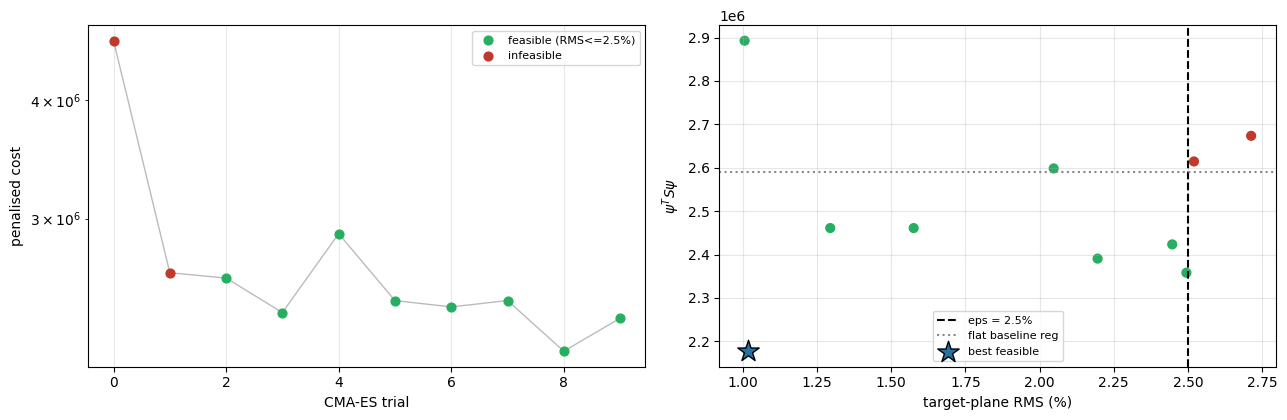

In [4]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.3))
# left: penalised cost vs trial (feasible vs infeasible)
nums = [r[0] for r in pen]; costs = [r[1] for r in pen]
feas = [bool(r[4]) for r in pen]
axL.plot(nums, costs, "-", color="#bbb", lw=1.0, zorder=1)
axL.scatter([n for n, f in zip(nums, feas) if f], [c for c, f in zip(costs, feas) if f],
            color="#27ae60", s=40, label=f"feasible (RMS<={eps*100:.1f}%)", zorder=3)
axL.scatter([n for n, f in zip(nums, feas) if not f], [c for c, f in zip(costs, feas) if not f],
            color="#c0392b", s=40, label="infeasible", zorder=3)
axL.set_yscale("log"); axL.set_xlabel("CMA-ES trial"); axL.set_ylabel("penalised cost")
axL.grid(alpha=0.3); axL.legend(fontsize=8)
# right: (RMS, reg_norm) of every trial + eps line + best feasible
rms_a = np.array([r[2] for r in pen]) * 100; reg_a = np.array([r[3] for r in pen])
axR.scatter(rms_a, reg_a, c=["#27ae60" if f else "#c0392b" for f in feas], s=40)
axR.axvline(eps * 100, color="k", ls="--", label=f"eps = {eps*100:.1f}%")
axR.axhline(flat["reg_norm"], color="#888", ls=":", label="flat baseline reg")
if np.isfinite(best_feas[0]):
    axR.scatter([best_feas[1]*100], [best_feas[0]], marker="*", s=260,
                color="#2471a3", edgecolor="k", zorder=5, label="best feasible")
axR.set_xlabel("target-plane RMS (%)"); axR.set_ylabel(r"$\psi^T S \psi$")
axR.grid(alpha=0.3); axR.legend(fontsize=8)
fig.tight_layout(); display(fig); plt.close(fig)


## (B) Pareto front — `(RMS, ψᵀSψ)` via NSGA-II

The penalty form gives ONE operating point. NSGA-II traces the whole `(RMS, ψᵀSψ)`
trade-off in one run; `study.best_trials` is the non-dominated set.

In [5]:
ARGS_PAR = make_args(pareto=True, deform_trials=30)
t0 = time.time()
study_par = ADV.run_deformation_search(ARGS_PAR, trials=ARGS_PAR.deform_trials)
t_par = time.time() - t0

# Dedupe the non-dominated set (NSGA-II re-evaluates params across generations).
seen, pareto = set(), []
for t in sorted(study_par.best_trials, key=lambda t: t.values[0]):
    key = (round(t.values[0], 6), round(t.values[1], 2))
    if key in seen:
        continue
    seen.add(key); pareto.append(t)
all_pts = [(t.user_attrs.get("rms"), t.user_attrs.get("reg_norm"))
           for t in study_par.trials
           if t.user_attrs.get("rms") is not None
           and np.isfinite(t.user_attrs.get("rms"))
           and np.isfinite(t.user_attrs.get("reg_norm", float("nan")))]
print(f"NSGA-II: {len(study_par.trials)} trials in {t_par:.1f} s,"
      f" {len(pareto)} Pareto-optimal points")
print(f"\n  {'RMS':>8}  {'reg_norm':>12}  bump (amp, cx, cy)")
print("  " + "-" * 52)
for t in pareto:
    rms_v, reg_v = t.values
    p = t.params
    print(f"  {rms_v*100:>7.2f}%  {reg_v:>12.3e}  "
          f"({p['bump_amp']:+.3f}, {p['bump_cx']:+.3f}, {p['bump_cy']:+.3f})")


NSGA-II: 30 trials in 21.8 s, 8 Pareto-optimal points

       RMS      reg_norm  bump (amp, cx, cy)
  ----------------------------------------------------
     0.52%     2.800e+06  (-0.032, -0.063, -0.013)
     0.58%     2.800e+06  (-0.032, -0.059, +0.007)
     0.61%     2.459e+06  (+0.021, -0.144, +0.141)
     1.06%     2.443e+06  (+0.021, -0.144, -0.095)
     1.46%     2.317e+06  (+0.047, -0.144, +0.141)
     1.46%     2.315e+06  (+0.047, -0.144, +0.141)
     1.84%     2.301e+06  (+0.033, -0.086, -0.095)
     2.35%     2.294e+06  (+0.033, -0.072, -0.095)


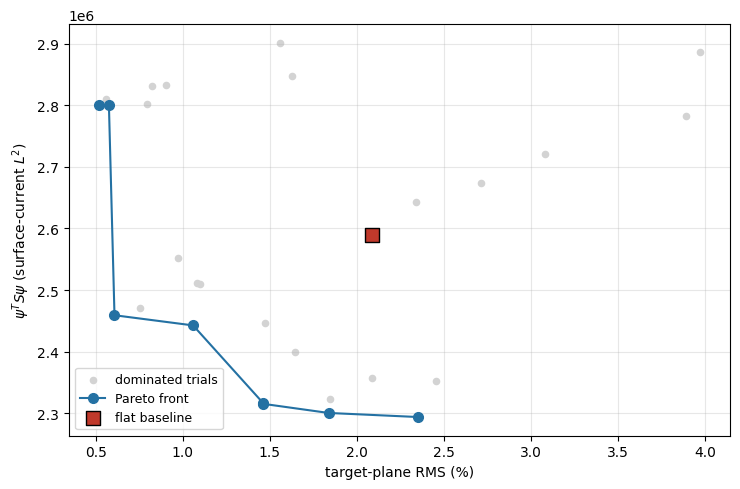

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5.0))
ra = np.array([p[0] for p in all_pts]) * 100; ga = np.array([p[1] for p in all_pts])
ax.scatter(ra, ga, s=20, c="lightgray", label="dominated trials")
rp = np.array([t.values[0] for t in pareto]) * 100
gp = np.array([t.values[1] for t in pareto])
ax.plot(rp, gp, "o-", color="#2471a3", lw=1.5, ms=7, label="Pareto front")
ax.scatter([flat["rms"]*100], [flat["reg_norm"]], marker="s", s=90, color="#c0392b",
           edgecolor="k", zorder=5, label="flat baseline")
ax.set_xlabel("target-plane RMS (%)"); ax.set_ylabel(r"$\psi^T S \psi$ (surface-current $L^2$)")
ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.tight_layout(); display(fig); plt.close(fig)


## Trade-off summary

`deformation.md` reports the three-row trade-off (flat baseline / accuracy-optimal /
constrained reg-min). We assemble it from the live studies: the flat baseline, the penalty
study's `best_feasible` (= `min ψᵀSψ s.t. RMS ≤ ε`), and the NSGA-II **accuracy end** (the
lowest-RMS non-dominated point — the operating point that scalar `min(RMS)` CMA-ES would
collapse to).

In [7]:
acc = min(pareto, key=lambda t: t.values[0])    # accuracy end of the Pareto front
rows = [
    ("flat baseline (no deform)",        flat["rms"],     flat["reg_norm"]),
    ("accuracy end (NSGA-II min RMS)",    acc.values[0],   acc.values[1]),
    ("min(reg) s.t. RMS <= %.1f%%" % (eps*100), best_feas[1], best_feas[0]),
]
print(f"{'mode':<34}{'RMS':>9}{'psi^T S psi':>15}")
print("-" * 58)
for name, rms, reg in rows:
    print(f"{name:<34}{rms*100:>8.2f}%{reg:>15.3e}")
print()
print("Reading: squeezing RMS below the baseline (accuracy end) typically SPENDS more")
print("surface-current energy than the flat baseline (localised concentrations); the")
print("constrained reg-min point accepts a within-spec RMS for markedly lower energy --")
print("the lower-left engineering corner of the front.  (Exact numbers are seed- and")
print("trial-count dependent; deformation.md used more trials.)")


mode                                    RMS    psi^T S psi
----------------------------------------------------------
flat baseline (no deform)             2.09%      2.590e+06
accuracy end (NSGA-II min RMS)        0.52%      2.800e+06
min(reg) s.t. RMS <= 2.5%             1.02%      2.177e+06

Reading: squeezing RMS below the baseline (accuracy end) typically SPENDS more
surface-current energy than the flat baseline (localised concentrations); the
constrained reg-min point accepts a within-spec RMS for markedly lower energy --
the lower-left engineering corner of the front.  (Exact numbers are seed- and
trial-count dependent; deformation.md used more trials.)


## Takeaways

- The outer CMA-ES / NSGA-II loop genuinely buys field uniformity and/or energy: the
  Pareto front sits below-left of the flat baseline.
- The penalty form (`--minimize-reg`) returns ONE within-spec, low-energy design;
  `--pareto` returns the whole curve so you can *choose* the spec — pick by budget
  (`deformation.md` § "When to pick `--pareto` vs `--minimize-reg`").
- Each Optuna trial rebuilds `A` (the surface moved), so the `RegularizedTSVD` cache is
  rebuilt per trial — the EXPENSIVE outer loop wrapping the cheap inner solve. When the
  surface is *fixed* and only the seminorm shape varies, the ACA factorisation is reused
  (see [`regularization.ipynb`](regularization.ipynb) and `demo_reg_hyperparam_aca.py`).
- **Design rule** (`deformation.md`): turn deformation OFF when the single-shot baseline is
  already sub-0.5 % — CMA-ES then wastes its budget and can regress.

Cross-references: prose → [`deformation.md`](deformation.md); the inner-solver menu and the
folded-Tikhonov peak-current Pareto front → [`regularization.ipynb`](regularization.ipynb);
method overview → [`theory.ipynb`](theory.ipynb); MCP topics
`streamfunction(topic=deformation)`, `optuna(topic=lab_applications)`.